# Do brainstorm ao dado — quais soluções a base sustenta
### EDA 03 · Projeto Integrador 3º Tri · PADS

**Objetivo.** O board do Miro produziu 17 ideias de solução. Este notebook submete cada uma a dois
filtros e desenvolve, com dado real, as que passam:

1. **Aderência** — a ideia responde ao problem statement da v1, e fala com o **decisor** que o
   próprio deck definiu (slide 7: poder público / SPTrans)?
2. **Viabilidade** — a base `acessibilidade_sp_2017_2019.csv` tem as colunas que a ideia exige?

O resultado separa as ideias em quatro tiers. **Dois deles viram trilha de trabalho aqui**, e o
notebook desenvolve os dois em paralelo, porque **a decisão de caminho ainda não foi tomada**:

| Trilha | Decisor | Pergunta que responde |
|---|---|---|
| **A · Pública** | SPTrans / Secretaria de Transporte | Onde a malha falha, para quem, e onde intervir primeiro |
| **B · Privada** *(escopo adicional)* | Empresa / RH / Real Estate corporativo | Quanto a localização de um endereço custa em mão de obra e em tempo do colaborador |

As duas usam **a mesma base** e **o mesmo grão** (hexágono H3, 2019). O que muda é a pergunta e
quem paga por ela. Este notebook não escolhe — ele mostra o que cada caminho tem de lastro.

> **Nota sobre o board.** As bolinhas coloridas do Miro (1, 2, 3, 5, 8, 13) não entram na avaliação:
> não sabemos se registraram valor ou esforço, e a leitura muda com isso. O critério aqui é só
> aderência × viabilidade.

In [1]:
import pandas as pd, numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", message=".*tight_layout.*")
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# --- paleta herdada dos EDAs 01 e 02 · S3 marca a trilha privada ---
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # público / alerta / privado
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#87857c"
SURFACE, GRID = "#fcfcfb", "#e6e5e1"
SEQ  = LinearSegmentedColormap.from_list("seq_blue", ["#f2f7fd", "#9dc4ee", "#2a78d6", "#123c6f"])
SEQ3 = LinearSegmentedColormap.from_list("seq_aqua", ["#f0faf6", "#8fd9c0", "#1baf7a", "#0c5c40"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 22,
    "figure.dpi": 110, "lines.linewidth": 2, "lines.markersize": 8,
})

def titulo(ax, t, sub=None):
    ax.set_title(t, color=INK)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=9, color=INK2, va="bottom")

def limpar_mapa(ax):
    # a grade H3 res 9 tem centroides a ~339 m; o marcador hexagonal aproxima a célula
    ax.set_aspect(1/np.cos(np.radians(-23.6)))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)

def barra_h(ax, sc, rotulo):
    # colorbar horizontal ABAIXO do mapa: entre dois painéis ela espreme a figura
    cb = plt.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.04, pad=0.02, aspect=32)
    cb.set_label(rotulo, fontsize=9, color=INK2)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=8.5)
    return cb

print("ambiente ok · pandas", pd.__version__)

ambiente ok · pandas 3.0.5


---
## 1 · Carga e montagem do grão de trabalho

A base vem no grão `(hexágono, ano, modo, período)`. Toda análise deste notebook é **hexágono ×
2019** — uma linha por lugar —, com os modos pivotados em colunas. É o recorte que o próprio
documento de features recomendou (Decisão 1).

In [2]:
BASE = Path.cwd()

def achar(*partes, padrao):
    for raiz in [BASE, BASE.parent, BASE.parent.parent]:
        cand = raiz.joinpath(*partes)
        if cand.is_dir():
            hits = sorted(cand.glob(padrao))
            if hits:
                return hits[0]
    raise FileNotFoundError(f"{partes} / {padrao}")

F = achar("base tratada", "Atividade Integradora 3", "dados", "saida",
          padrao="acessibilidade_sp_2017_2019.csv")
df = pd.read_csv(F, low_memory=False)
df.columns = [c.strip().lstrip("﻿") for c in df.columns]

TOT = {a: df[(df.ano == a) & (df.modo == "transporte_publico")
             & (df.periodo == "pico")].empregos_total.sum() for a in [2017, 2018, 2019]}
TOT19 = TOT[2019]
print(f"base: {len(df):,} linhas · {df.id_hex.nunique():,} hexágonos")
print(f"empregos na cidade em 2019: {TOT19:,}")

base: 140,784 linhas · 10,056 hexágonos
empregos na cidade em 2019: 3,461,972


In [3]:
ACC = ["empregos_15min", "empregos_30min", "empregos_45min", "empregos_60min",
       "empregos_90min", "empregos_120min", "empregos_baixa_esc_60min",
       "empregos_media_esc_60min", "empregos_alta_esc_60min",
       "saude_30min", "saude_60min", "escolas_60min", "cras_60min",
       "matriculas_60min", "pessoas_que_alcancam_60min"]
TMP = [c for c in df.columns if c.startswith("tempo_")]

def corte(modo, periodo, cols):
    s = df[(df.ano == 2019) & (df.modo == modo) & (df.periodo == periodo)]
    return s.set_index("id_hex")[cols]

fixo = (df[(df.ano == 2019) & (df.modo == "transporte_publico") & (df.periodo == "pico")]
        .set_index("id_hex").drop(columns=ACC + TMP + ["modo", "periodo"]))

hx = (fixo
      .join(corte("transporte_publico", "pico",      ACC + TMP).add_prefix("tp_"))
      .join(corte("transporte_publico", "fora_pico", ACC).add_prefix("tpf_"))
      .join(corte("caminhada",  "nao_se_aplica", ACC + TMP).add_prefix("cam_"))
      .join(corte("bicicleta",  "nao_se_aplica", ACC).add_prefix("bic_"))
      .join(corte("automovel",  "pico",          ACC + TMP).add_prefix("car_")))

hx = hx[hx.pop_total > 0].reset_index()
print(f"grão de trabalho: {len(hx):,} hexágonos habitados × {hx.shape[1]} colunas")
print(f"população coberta: {hx.pop_total.sum():,.0f}")

grão de trabalho: 9,704 hexágonos habitados × 145 colunas
população coberta: 11,163,678


In [4]:
# --- métricas derivadas usadas pelas duas trilhas ---
lat0 = hx.lat.mean()
hx["x_m"] = (hx.lon - hx.lon.mean()) * 111320 * np.cos(np.radians(lat0))
hx["y_m"] = (hx.lat - hx.lat.mean()) * 110540

SE = (-46.6333, -23.5505)                       # Praça da Sé
w = hx.empregos_total.clip(lower=0)
POLO = (np.average(hx.lon, weights=w), np.average(hx.lat, weights=w))   # centroide dos empregos

def km_ate(ponto):
    return np.hypot((hx.lon - ponto[0]) * 111320 * np.cos(np.radians(lat0)),
                    (hx.lat - ponto[1]) * 110540) / 1000

hx["dist_centro_km"] = km_ate(SE)
hx["dist_polo_km"]   = km_ate(POLO)

hx["pct60"]     = hx.tp_empregos_60min / TOT19 * 100          # alcance, em % do mercado
hx["dep_pico"]  = ((hx.tp_empregos_60min - hx.tpf_empregos_60min)
                   / hx.tpf_empregos_60min.replace(0, np.nan) * 100)
hx["razao_ap"]  = hx.tp_empregos_60min / hx.tp_pessoas_que_alcancam_60min.replace(0, np.nan)
hx["pea"]       = hx[["pop_19a24", "pop_25a39", "pop_40a69"]].sum(axis=1)

# minutos para alcançar 25% e 50% do mercado (inversão da curva de acesso)
CORTES = {"tp_empregos_15min": 15, "tp_empregos_30min": 30, "tp_empregos_60min": 60,
          "tp_empregos_90min": 90, "tp_empregos_120min": 120}
Y = (hx[list(CORTES)].to_numpy() / TOT19 * 100)
X = np.array(list(CORTES.values()), dtype=float)
hx["min_p25"] = [np.interp(25, y, X) for y in Y]
hx["min_p50"] = [np.interp(50, y, X) for y in Y]
hx["satura_25"] = Y[:, -1] < 25        # nunca alcança 25% nem em 2h -> censura à direita

print(f"polo de empregos: ({POLO[0]:.4f}, {POLO[1]:.4f}) · a "
      f"{np.hypot((POLO[0]-SE[0])*111320*np.cos(np.radians(lat0)), (POLO[1]-SE[1])*110540)/1000:.1f} km da Sé")
print(f"hexágonos que não alcançam 25% do mercado nem em 2h: {hx.satura_25.sum():,} "
      f"({hx.loc[hx.satura_25, 'pop_total'].sum()/1e6:.2f} mi de pessoas)")
hx[["pct60", "min_p25", "dep_pico", "razao_ap"]].describe().round(1)

polo de empregos: (-46.6420, -23.5697) · a 2.3 km da Sé
hexágonos que não alcançam 25% do mercado nem em 2h: 875 (0.15 mi de pessoas)


,pct60,min_p25,dep_pico,razao_ap
count,"9,704.00","9,704.00","9,537.00","9,704.00"
mean,18.50,73.40,15.70,0.40
std,18.30,23.90,68.30,0.30
min,0.00,29.90,-91.80,0.00
25%,3.20,54.20,4.90,0.20
50%,12.20,69.40,9.30,0.40
75%,30.50,89.90,16.10,0.70
max,79.50,120.00,"3,905.30",2.70


---
## 2 · O filtro de viabilidade: o que a base simplesmente não tem

Antes de discutir mérito, um teste objetivo. Várias ideias do board pressupõem dados de **operação
realizada** (atraso, tempo real), de **rede** (linha, parada, headway) ou de **preço** (tarifa). A
base é de acessibilidade **potencial**, calculada sobre a rede *programada* de 2017–2019.

In [5]:
TERMOS = ["atraso", "delay", "realiz", "rota", "route", "linha", "parada", "stop",
          "headway", "espera", "velocid", "tarifa", "preco", "custo", "gtfs", "tempo_real"]
achados = {t: [c for c in df.columns if t in c.lower()] for t in TERMOS}
inv = pd.DataFrame({"termo procurado": list(achados),
                    "colunas na base": ["—" if not v else ", ".join(v) for v in achados.values()]})
print("O que a base NÃO tem (busca literal no cabeçalho das 69 colunas):")
inv

O que a base NÃO tem (busca literal no cabeçalho das 69 colunas):


,termo procurado,colunas na base
0,atraso,—
1,delay,—
2,realiz,—
3,rota,—
4,route,—
5,linha,—
6,parada,—
7,stop,—
8,headway,—
9,espera,—


In [6]:
IDEIAS = [
 # ideia,                                                      trilha,      viável?, o que falta / o que sustenta
 ("cálculo do índice → diagnóstico por região (decomposição)",  "A · pública", "✅", "acesso, renda, distância, resíduo — tudo na base"),
 ("indicador para cobrar SP Trans",                             "A · pública", "✅", "déficit de acesso ponderado por população"),
 ("mapa igual o do visquill",                                   "A · pública", "✅", "lon/lat + grade .gpkg dos 10.056 hexágonos"),
 ("static dash pro governo / dashboard",                        "A · pública", "✅", "camada de entrega das métricas acima"),
 ("índice variável — desmembrar por cada fator",                "A · pública", "⚠️", "fatores redundantes entre si (ver seção 5)"),
 ("índice único que consolide N fatores",                       "A · pública", "⚠️", "idem — vira um fator com cinco chapéus"),
 ("IQT versão empresa",                                         "B · privada", "✅", "acessibilidade passiva por endereço"),
 ("custo economizado do colaborador em casa",                   "B · privada", "⚠️", "precisa de valor do tempo (premissa externa)"),
 ("viabilidade de frota própria / trajetos gargalo",            "B · privada", "⚠️", "gargalo sai do dado; trajeto exige roteamento"),
 ("regressão custo commute",                                    "C · externa", "⚠️", "falta tarifa SPTrans e rendimento atual"),
 ("API de consulta do índice",                                  "C · externa", "➖", "infraestrutura — entrega, não produz análise"),
 ("modelo estilo waze de eficiência de rota",                   "D · inviável","❌", "exige tempo real; base é rede programada"),
 ("otimizador de rotas de transporte corporativo",              "D · inviável","❌", "exige motor de roteamento + matriz OD"),
 ("propor linhas alternativas estilo fura-fila",                "D · inviável","❌", "exige GTFS, demanda e traçado"),
 ("clusterização por métricas de atraso",                       "D · inviável","❌", "zero colunas de atraso na base"),
 ("despertador do CLT (alerta de trânsito)",                    "D · inviável","❌", "tempo real; e serve o afetado, não o decisor"),
]
board = pd.DataFrame(IDEIAS, columns=["ideia do board", "trilha", "viável", "o que sustenta / o que falta"])
print(board.trilha.value_counts().sort_index().to_string())
board

trilha
A · pública     6
B · privada     3
C · externa     2
D · inviável    5


,ideia do board,trilha,viável,o que sustenta / o que falta
0,cálculo do índice → diagnóstico por região (decomposição),A · pública,✅,"acesso, renda, distância, resíduo — tudo na base"
1,indicador para cobrar SP Trans,A · pública,✅,déficit de acesso ponderado por população
2,mapa igual o do visquill,A · pública,✅,lon/lat + grade .gpkg dos 10.056 hexágonos
3,static dash pro governo / dashboard,A · pública,✅,camada de entrega das métricas acima
4,índice variável — desmembrar por cada fator,A · pública,⚠️,fatores redundantes entre si (ver seção 5)
5,índice único que consolide N fatores,A · pública,⚠️,idem — vira um fator com cinco chapéus
6,IQT versão empresa,B · privada,✅,acessibilidade passiva por endereço
7,custo economizado do colaborador em casa,B · privada,⚠️,precisa de valor do tempo (premissa externa)
8,viabilidade de frota própria / trajetos gargalo,B · privada,⚠️,gargalo sai do dado; trajeto exige roteamento
9,regressão custo commute,C · externa,⚠️,falta tarifa SPTrans e rendimento atual


> **Achado 1 — cinco das dezesseis ideias morrem por ausência de dado, não por mérito.**
> Waze de rota, otimizador corporativo, linhas alternativas, clusterização por atraso e despertador
> do CLT dependem todos de **operação realizada ou de rede** — as duas coisas que esta base não tem.
> O plano de análise v0.2 já havia colocado o gap "programado × realizado" fora do escopo; a base da
> AI3 confirma isso no cabeçalho.
>
> Há ainda um filtro de **aderência**, independente do dado: o despertador do CLT serve o
> **trabalhador**, que o slide 7 do deck define como quem *"carece de poder de decisão"*. Uma
> solução para quem não decide não move o problema.

---
# Trilha A · Pública

**Decisor:** SPTrans / Secretaria de Transporte. **Pergunta:** onde a malha falha, para quem, e onde
intervir primeiro. Três entregas encadeadas.

## 3 · A.1 — Decomposição regional: São Paulo são três cidades

A segunda frase do problem statement é *"a malha não atende a população de forma homogênea
geograficamente"*. Ela é testável: se o território for homogêneo, um agrupamento não encontra
estrutura. Se não for, encontra — e nomeia os grupos.

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

VARS = ["pct60", "dep_pico", "dist_centro_km", "renda_per_capita", "razao_ap"]
d = hx[VARS + ["id_hex", "lon", "lat", "pop_total", "decil_renda"]].replace([np.inf, -np.inf], np.nan).dropna()
Xs = StandardScaler().fit_transform(d[VARS])

print("quantos tipos de território existem de fato?")
print("(a inércia cai suave — não há k obviamente certo; k=4 é escolha, e ela é declarada)\n")
for k in range(2, 7):
    km = KMeans(k, n_init=10, random_state=0).fit(Xs)
    tam = pd.Series(km.labels_).value_counts().sort_index().tolist()
    print(f"  k={k}: inércia {km.inertia_:>9,.0f} | tamanhos {tam}")

quantos tipos de território existem de fato?
(a inércia cai suave — não há k obviamente certo; k=4 é escolha, e ela é declarada)

  k=2: inércia    27,590 | tamanhos [5857, 3680]
  k=3: inércia    20,929 | tamanhos [3680, 5851, 6]
  k=4: inércia    16,116 | tamanhos [3389, 4887, 7, 1254]
  k=5: inércia    13,072 | tamanhos [2403, 2821, 881, 7, 3425]


  k=6: inércia    11,624 | tamanhos [2172, 2180, 7, 678, 1614, 2886]


In [8]:
K = 4
km = KMeans(K, n_init=10, random_state=0).fit(Xs)
d = d.assign(cluster=km.labels_)

perfil = (d.groupby("cluster")
          .agg(hexagonos=("pct60", "size"), populacao=("pop_total", "sum"),
               acesso_pct=("pct60", "median"), dep_pico=("dep_pico", "median"),
               dist_centro=("dist_centro_km", "median"), renda=("renda_per_capita", "median"),
               decil=("decil_renda", "median")))
perfil["pop_pct"] = perfil.populacao / perfil.populacao.sum() * 100

# nomeia por acesso mediano, do pior para o melhor; grupos minúsculos viram "outliers"
ordem = perfil.sort_values("acesso_pct").index.tolist()
nomes = {}
rotulos = ["Periferia mal servida", "Cidade intermediária", "Centro expandido"]
i = 0
for c in ordem:
    if perfil.loc[c, "hexagonos"] < 50:
        nomes[c] = "Outliers (grade)"
    else:
        nomes[c] = rotulos[i]; i += 1
perfil["territorio"] = [nomes[c] for c in perfil.index]
d["territorio"] = d.cluster.map(nomes)
perfil.sort_values("acesso_pct").round(1)

,hexagonos,populacao,acesso_pct,dep_pico,dist_centro,renda,decil,pop_pct,territorio
cluster,,,,,,,,,
2,7,486,0.00,"1,852.60",31.90,229.60,1.00,0.00,Outliers (grade)
1,4887,5635317,3.70,11.90,20.10,470.80,3.00,50.50,Periferia mal servida
0,3389,4003930,25.40,9.00,9.80,972.00,7.00,35.90,Cidade intermediária
3,1254,1518821,49.00,3.70,7.00,"3,331.90",10.00,13.60,Centro expandido


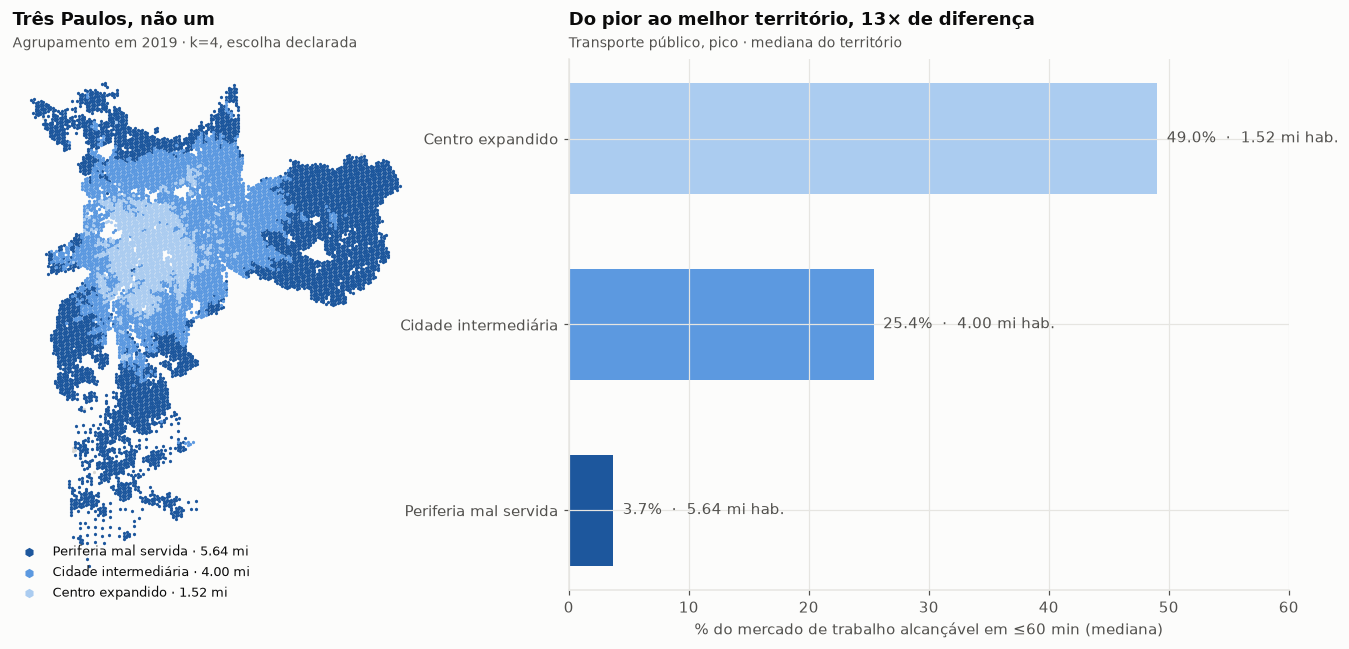

Periferia mal servida: 5.64 mi de pessoas (50.5% da cidade), acesso 3.7%, renda R$ 471, 20 km do centro
Centro expandido: 1.52 mi (13.6%), acesso 49.0%, renda R$ 3,332, 7 km

razão de acesso entre os dois: 13.3×


In [9]:
# cor por nível de acesso; os hexágonos de borda ficam cinzas e fora da narrativa
reais = perfil[perfil.territorio != "Outliers (grade)"].sort_values("acesso_pct").territorio.tolist()
CORES = {t: SEQ(v) for t, v in zip(reais, [0.85, 0.52, 0.28])}
CORES["Outliers (grade)"] = "#d9d8d4"

fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.0), width_ratios=[1, 1.15])

ax = axes[0]
for t in ["Outliers (grade)"] + reais:
    s = d[d.territorio == t]
    if not len(s):
        continue
    ax.scatter(s.lon, s.lat, s=5.5, marker="h", color=CORES[t], linewidths=0,
               label=(f"{t} · {s.pop_total.sum()/1e6:.2f} mi" if t in reais else None),
               rasterized=True)
limpar_mapa(ax)
ax.legend(frameon=False, fontsize=8.5, loc="lower left", markerscale=2.6,
          bbox_to_anchor=(-0.02, -0.04))
titulo(ax, "Três Paulos, não um", "Agrupamento em 2019 · k=4, escolha declarada")

ax = axes[1]
p = perfil[perfil.territorio != "Outliers (grade)"].sort_values("acesso_pct")
y = np.arange(len(p))
b = ax.barh(y, p.acesso_pct, color=[CORES[t] for t in p.territorio], height=0.6)
ax.set_yticks(y, p.territorio)
for r, v, pop in zip(b, p.acesso_pct, p.populacao):
    ax.text(v + 0.8, r.get_y() + r.get_height()/2, f"{v:.1f}%  ·  {pop/1e6:.2f} mi hab.",
            va="center", fontsize=9.5, color=INK2)
ax.set_xlim(0, 60); ax.set_xlabel("% do mercado de trabalho alcançável em ≤60 min (mediana)")
titulo(ax, f"Do pior ao melhor território, {p.acesso_pct.iloc[-1]/p.acesso_pct.iloc[0]:.0f}× de diferença",
       "Transporte público, pico · mediana do território")
plt.tight_layout(); plt.subplots_adjust(wspace=0.06); plt.show()

pior, melhor = p.iloc[0], p.iloc[-1]
print(f"{pior.territorio}: {pior.populacao/1e6:.2f} mi de pessoas ({pior.pop_pct:.1f}% da cidade), "
      f"acesso {pior.acesso_pct:.1f}%, renda R$ {pior.renda:,.0f}, {pior.dist_centro:.0f} km do centro")
print(f"{melhor.territorio}: {melhor.populacao/1e6:.2f} mi ({melhor.pop_pct:.1f}%), "
      f"acesso {melhor.acesso_pct:.1f}%, renda R$ {melhor.renda:,.0f}, {melhor.dist_centro:.0f} km")
print(f"\nrazão de acesso entre os dois: {melhor.acesso_pct/pior.acesso_pct:.1f}×")

> **Achado 2 — o grupo do problema é o dobro do que o deck afirmou.**
> O slide 6 falava em **2,25 mi de pessoas** em setores com dificuldade. A decomposição encontra um
> território de **periferia mal servida** com **5,64 milhões de moradores — 50,5% da cidade** —,
> mediana de acesso de **3,7%** do mercado de trabalho, renda per capita de **R$ 471** e **20 km** do
> centro. Contra o centro expandido (1,52 mi de pessoas, 13,6%), a razão de acesso é de **13,3×**.
>
> Isso não contradiz o deck: aquele número saía de um recorte diferente (e de uma base cuja
> população estava quebrada, como o EDA 01 mostrou). O ponto é que **agora dá para dizer quem é o
> grupo, onde ele está e quantos são**, com um critério reproduzível.
>
> **A escolha declarada:** k=4 (três territórios + 7 hexágonos de borda). A inércia cai de forma
> suave, ou seja, não existe um número "certo" de grupos — o que existe é um corte defensável. Com
> k=3 a cidade se parte em apenas duas metades; k=4 é o menor k que separa centro de intermediária.

---
## 4 · A.2 — O indicador para cobrar a SPTrans: déficit em pessoas × pontos percentuais

Um mapa de acesso mostra onde é ruim. Um decisor precisa de mais: **onde uma intervenção rende
mais**. A métrica que faz isso é o déficit ponderado — pessoas multiplicadas pelos pontos
percentuais que faltam para a mediana da cidade.

Um hexágono péssimo com 40 moradores perde para um mediano com 4 mil. É assim que se prioriza
política pública.

In [10]:
def percentil_pond(valores, pesos, q):
    o = np.argsort(valores)
    v, w = np.asarray(valores)[o], np.asarray(pesos)[o]
    c = np.cumsum(w) - 0.5 * w
    return np.interp(q / 100 * w.sum(), c, v)

MEDIANA_CIDADE = percentil_pond(hx.pct60, hx.pop_total, 50)
Q1_CIDADE      = percentil_pond(hx.pct60, hx.pop_total, 25)
hx["deficit"]  = (hx.pop_total * (MEDIANA_CIDADE - hx.pct60)).clip(lower=0)

print(f"mediana da cidade, ponderada pela população: {MEDIANA_CIDADE:.1f}% do mercado")
print(f"1º quartil ponderado                       : {Q1_CIDADE:.1f}%")
print(f"déficit total da cidade: {hx.deficit.sum()/1e6:.1f} mi de pessoa×p.p.\n")

for n in [100, 200, 500, 1000]:
    t = hx.nlargest(n, "deficit")
    print(f"  top {n:>4} hexágonos ({n/len(hx)*100:4.1f}% da cidade): "
          f"{t.deficit.sum()/hx.deficit.sum()*100:4.1f}% do déficit · "
          f"{t.pop_total.sum():>9,.0f} moradores · acesso mediano {t.pct60.median():4.1f}%")

mediana da cidade, ponderada pela população: 13.5% do mercado
1º quartil ponderado                       : 5.4%
déficit total da cidade: 42.2 mi de pessoa×p.p.

  top  100 hexágonos ( 1.0% da cidade): 10.3% do déficit ·   409,152 moradores · acesso mediano  2.6%
  top  200 hexágonos ( 2.1% da cidade): 17.8% do déficit ·   723,247 moradores · acesso mediano  2.7%
  top  500 hexágonos ( 5.2% da cidade): 35.4% do déficit · 1,478,984 moradores · acesso mediano  3.0%
  top 1000 hexágonos (10.3% da cidade): 56.6% do déficit · 2,473,090 moradores · acesso mediano  3.3%


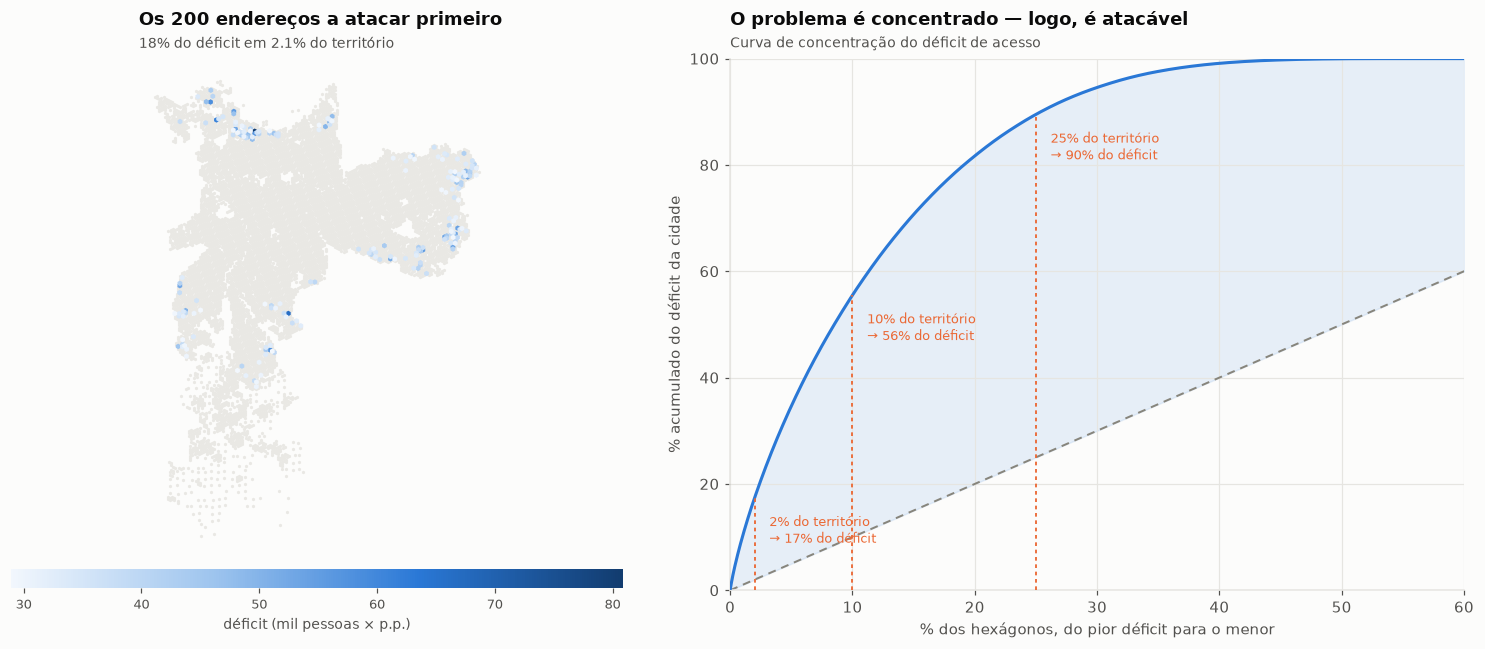

os 200 hexágonos-alvo somam 723,247 moradores
  acesso mediano 2.7% · distância mediana ao centro 21 km
  renda per capita mediana R$ 423
  minutos para alcançar 25% do mercado: 93 (cidade: 69)


In [11]:
TOPN = 200
alvo = hx.nlargest(TOPN, "deficit").copy()

fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.0), width_ratios=[1, 1.2])

ax = axes[0]
ax.scatter(hx.lon, hx.lat, s=5.5, marker="h", color="#e9e8e4", linewidths=0, rasterized=True)
sc = ax.scatter(alvo.lon, alvo.lat, s=13, marker="h", c=alvo.deficit/1000, cmap=SEQ,
                linewidths=0, rasterized=True)
limpar_mapa(ax)
barra_h(ax, sc, "déficit (mil pessoas × p.p.)")
titulo(ax, f"Os {TOPN} endereços a atacar primeiro",
       f"{alvo.deficit.sum()/hx.deficit.sum()*100:.0f}% do déficit em {TOPN/len(hx)*100:.1f}% do território")

ax = axes[1]
ordenado = hx.sort_values("deficit", ascending=False)
cum = ordenado.deficit.cumsum() / ordenado.deficit.sum() * 100
xx = np.arange(1, len(ordenado) + 1) / len(ordenado) * 100
ax.plot(xx, cum, color=S1, zorder=3)
ax.plot([0, 100], [0, 100], color=INK3, lw=1.3, ls=(0, (4, 3)), zorder=2)
ax.fill_between(xx, cum, xx, color=S1, alpha=0.10, zorder=1)
for marca in [2, 10, 25]:
    v = np.interp(marca, xx, cum)
    ax.plot([marca, marca], [0, v], color=S2, lw=1.2, ls=(0, (2, 2)), zorder=4)
    ax.text(marca + 1.2, v - 3, f"{marca}% do território\n→ {v:.0f}% do déficit",
            fontsize=8.5, color=S2, va="top")
ax.set_xlim(0, 60); ax.set_ylim(0, 100)
ax.set_xlabel("% dos hexágonos, do pior déficit para o menor")
ax.set_ylabel("% acumulado do déficit da cidade")
titulo(ax, "O problema é concentrado — logo, é atacável",
       "Curva de concentração do déficit de acesso")
plt.tight_layout(); plt.subplots_adjust(wspace=0.16); plt.show()

print(f"os {TOPN} hexágonos-alvo somam {alvo.pop_total.sum():,.0f} moradores")
print(f"  acesso mediano {alvo.pct60.median():.1f}% · distância mediana ao centro {alvo.dist_centro_km.median():.0f} km")
print(f"  renda per capita mediana R$ {alvo.renda_per_capita.median():,.0f}")
print(f"  minutos para alcançar 25% do mercado: {alvo.min_p25.median():.0f} (cidade: {hx.min_p25.median():.0f})")

> **Achado 3 — 2% do território carrega 18% do déficit.**
> A curva é fortemente côncava: dá para endereçar uma parcela desproporcional do problema com uma
> lista curta. Esse é o formato que um órgão consegue usar — não um índice, uma **fila de
> prioridade** com hexágono, população e quanto falta.
>
> **Cuidado de leitura:** o déficit é uma métrica de *oportunidade de ganho*, não de justiça. Ele
> favorece lugares populosos. Se o critério político for equidade pura, a ordenação muda — e essa é
> uma escolha de valor que o grupo tem de declarar, não esconder no código.

---
## 5 · A.3 — Quanto do acesso é a rede, e quanto é só geografia econômica

A pergunta que dá lastro a "cobrar a SPTrans": **quanto do acesso ruim é culpa da rede de
transporte, e quanto é consequência inevitável de morar longe do polo de empregos?**

O teste: prever o acesso **sem usar nenhuma variável de acessibilidade** — só localização, quem mora
ali e o que existe ali. O que o modelo não explica é, por eliminação, a rede.

> **Validação por blocos espaciais, não aleatória.** Hexágonos vizinhos se parecem; um split
> aleatório coloca o vizinho do treino no teste e infla a métrica. Medimos os dois para mostrar o
> tamanho do problema.

In [12]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import r2_score
from scipy.spatial import cKDTree

m = hx.dropna(subset=["renda_per_capita", "decil_renda"]).copy()
m["pct_negra"] = m.pop_negra / m[["pop_branca", "pop_negra", "pop_amarela", "pop_indigena"]].sum(axis=1).replace(0, np.nan)
m["pct_negra"] = m.pct_negra.fillna(0)

SOCIO = ["pop_total", "pea", "pct_negra", "renda_per_capita", "decil_renda"]
USO   = ["empregos_total", "empregos_baixa_esc", "empregos_alta_esc",
         "escolas_total", "matriculas_total", "saude_total", "cras_total"]
GEO   = ["dist_centro_km", "dist_polo_km"]
XY    = ["x_m", "y_m"]

y, wt = m.pct60.values, m.pop_total.values
blocos = (pd.cut(m.x_m, 6, labels=False) * 6 + pd.cut(m.y_m, 6, labels=False)).astype(int).values

def avaliar(feats, nome, cv, groups=None):
    X = m[feats].values; r2 = []; pred = np.zeros(len(m))
    it = cv.split(X, y, groups) if groups is not None else cv.split(X)
    for tr, te in it:
        mod = HistGradientBoostingRegressor(max_iter=180, learning_rate=0.1,
                                            max_depth=5, random_state=0)
        mod.fit(X[tr], y[tr], sample_weight=wt[tr])
        pred[te] = mod.predict(X[te])
        r2.append(r2_score(y[te], pred[te], sample_weight=wt[te]))
    print(f"  {nome:<46} R² = {np.mean(r2):.3f}")
    return pred, np.mean(r2)

print("Preditores SEM nenhuma variável de acessibilidade:\n")
print("[a] o erro comum — validação aleatória")
_, r_rand = avaliar(GEO + SOCIO + USO + XY, "tudo, split aleatório", KFold(5, shuffle=True, random_state=0))

print("\n[b] validação por blocos espaciais (6×6 = 27 blocos ocupados)")
_,      r_geo = avaliar(GEO,                    "só distância (centro + polo)",      GroupKFold(6), blocos)
_,      r_soc = avaliar(GEO + SOCIO,            "+ sociodemografia",                 GroupKFold(6), blocos)
p_gsu,  r_uso = avaliar(GEO + SOCIO + USO,      "+ uso do solo  (sem coordenada)",   GroupKFold(6), blocos)
_,      r_xy  = avaliar(GEO + SOCIO + USO + XY, "+ coordenada crua (x, y)",          GroupKFold(6), blocos)

print(f"\ninflação do R² pelo split aleatório: +{(r_rand - r_xy)/r_xy*100:.0f}% ({r_rand:.3f} vs {r_xy:.3f})")
print(f"ganho da coordenada crua sobre os atributos do lugar: +{r_xy - r_uso:.3f} de R²")

Preditores SEM nenhuma variável de acessibilidade:

[a] o erro comum — validação aleatória


  tudo, split aleatório                          R² = 0.933

[b] validação por blocos espaciais (6×6 = 27 blocos ocupados)


  só distância (centro + polo)                   R² = 0.464


  + sociodemografia                              R² = 0.631


  + uso do solo  (sem coordenada)                R² = 0.675


  + coordenada crua (x, y)                       R² = 0.766

inflação do R² pelo split aleatório: +22% (0.933 vs 0.766)
ganho da coordenada crua sobre os atributos do lugar: +0.091 de R²


Moran's I do acesso  : 0.957   (autocorrelação espacial extrema)
Moran's I do resíduo : 0.703   (o que sobra ainda é estruturado)
desvio do resíduo    : 8.0 p.p. · p5 -12.4 · p95 +14.4


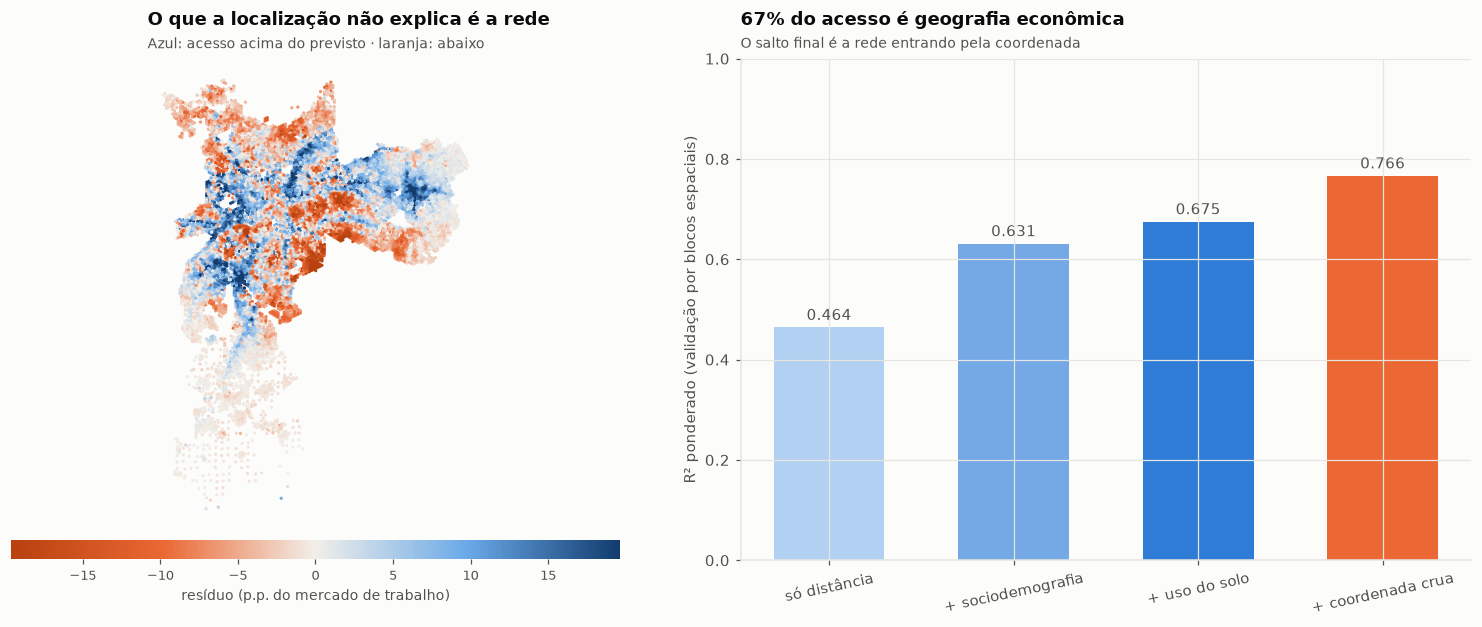

In [13]:
m["pred"] = p_gsu
m["residuo"] = m.pct60 - m.pred      # + = mais acesso do que o lugar explica

def moran(vals, coords, k=6):
    z = vals - vals.mean()
    _, idx = cKDTree(coords).query(coords, k=k + 1)
    return np.sum(z * z[idx[:, 1:]].mean(axis=1)) / np.sum(z ** 2)

xy = m[["x_m", "y_m"]].values
print(f"Moran's I do acesso  : {moran(m.pct60.values, xy):.3f}   (autocorrelação espacial extrema)")
print(f"Moran's I do resíduo : {moran(m.residuo.values, xy):.3f}   (o que sobra ainda é estruturado)")
print(f"desvio do resíduo    : {m.residuo.std():.1f} p.p. · p5 {m.residuo.quantile(.05):+.1f} · p95 {m.residuo.quantile(.95):+.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.8), width_ratios=[1, 1.2])
lim = np.percentile(np.abs(m.residuo), 97)
DIV = LinearSegmentedColormap.from_list("div", ["#b8410f", "#eb6834", "#f2efe9", "#6aa9e8", "#123c6f"])

ax = axes[0]
sc = ax.scatter(m.lon, m.lat, c=m.residuo.clip(-lim, lim), s=5.5, marker="h", cmap=DIV,
                vmin=-lim, vmax=lim, linewidths=0, rasterized=True)
limpar_mapa(ax)
barra_h(ax, sc, "resíduo (p.p. do mercado de trabalho)")
titulo(ax, "O que a localização não explica é a rede",
       "Azul: acesso acima do previsto · laranja: abaixo")

ax = axes[1]
etapas = ["só distância", "+ sociodemografia", "+ uso do solo", "+ coordenada crua"]
vals = [r_geo, r_soc, r_uso, r_xy]
b = ax.bar(etapas, vals, color=[SEQ(0.25), SEQ(0.45), SEQ(0.65), S2], width=0.6)
for r, v in zip(b, vals):
    ax.text(r.get_x() + r.get_width()/2, v + 0.015, f"{v:.3f}", ha="center", fontsize=10, color=INK2)
ax.set_ylim(0, 1.0); ax.set_ylabel("R² ponderado (validação por blocos espaciais)")
ax.tick_params(axis="x", labelrotation=12)
titulo(ax, f"{r_uso:.0%} do acesso é geografia econômica",
       "O salto final é a rede entrando pela coordenada")
plt.tight_layout(); plt.subplots_adjust(wspace=0.18); plt.show()

> **Achado 4 — dois terços do problema não são da SPTrans; um terço é.**
> Distância ao polo de empregos, quem mora ali e o que existe ali explicam **R² = 0,68** do acesso.
> Acrescentar a coordenada crua leva a **0,77** — esses **+0,09** são padrão espacial que nenhum
> atributo do lugar contém: é a rede. E o resíduo tem **Moran's I de 0,70**, ou seja, não é ruído,
> é geografia de infraestrutura.
>
> Isso dá ao indicador de cobrança uma qualidade rara: ele **separa o que é responsabilidade da
> operadora do que é herança da forma urbana**. Um hexágono com resíduo −10 p.p. tem acesso pior do
> que lugares equivalentes — e aí a pergunta para a SPTrans é legítima.
>
> **O alerta de método:** o split aleatório dá R² 0,94 contra 0,77 do split espacial. Quem
> apresentar o primeiro número está apresentando um artefato — o vizinho do treino estava no teste.

---
# Trilha B · Privada — *escopo adicional*

**Decisor:** empresa (RH, real estate corporativo, operações). **Pergunta:** quanto a localização de
um endereço custa em mão de obra disponível e em tempo do colaborador.

> **Por que esta trilha existe neste notebook.** O slide 9 do deck registrou como dúvida em aberto
> *"se o caminho de entrada é o público (estrutural) ou uma cunha corporativa"*. A decisão não foi
> tomada. Esta seção mostra o que a **mesma base** entrega se o caminho for o privado — para que a
> escolha aconteça olhando as duas opções prontas, e não no abstrato.
>
> Escolher a Trilha B **não é um ajuste de foco: é reescrever o problem statement**. O afetado deixa
> de ser o trabalhador da periferia e passa a ser a empresa; o decisor deixa de ser a SPTrans. As
> duas trilhas são coerentes; o que não funciona é apresentar as duas como se fossem uma.

## 6 · B.1 — A coluna que sustenta a trilha inteira: acessibilidade passiva

`pessoas_que_alcancam_60min` inverte a pergunta da base. Em vez de *"a quantos empregos chego daqui"*,
ela responde *"quantas pessoas chegam **até aqui** em 60 minutos de transporte público"*. É,
literalmente, o **tamanho do mercado de trabalho de um endereço**.

In [14]:
hx["mao_de_obra_60min"] = hx.tp_pessoas_que_alcancam_60min

print("mão de obra ao alcance (60 min, TP, pico) — todos os hexágonos habitados:")
q = hx.mao_de_obra_60min.quantile([.10, .25, .50, .75, .90])
for k, v in q.items():
    print(f"  p{int(k*100):>3}: {v:>12,.0f}")
print(f"  razão p90/p10: {q[.90]/q[.10]:.1f}×")

# onde o emprego realmente está
emp = hx.nlargest(300, "empregos_total").copy()
print(f"\nnos 300 hexágonos com mais vagas ({emp.empregos_total.sum()/hx.empregos_total.sum()*100:.0f}% dos empregos da cidade):")
print(f"  mão de obra ao alcance — mediana {emp.mao_de_obra_60min.median():,.0f}")
print(f"  pior endereço  : {emp.mao_de_obra_60min.min():>10,.0f}")
print(f"  melhor endereço: {emp.mao_de_obra_60min.max():>10,.0f}")
print(f"  razão melhor/pior: {emp.mao_de_obra_60min.max()/emp.mao_de_obra_60min.min():.0f}×")

mão de obra ao alcance (60 min, TP, pico) — todos os hexágonos habitados:
  p 10:      176,513
  p 25:      563,571
  p 50:    1,113,579
  p 75:    1,716,868
  p 90:    2,343,711
  razão p90/p10: 13.3×

nos 300 hexágonos com mais vagas (38% dos empregos da cidade):
  mão de obra ao alcance — mediana 2,542,114
  pior endereço  :     50,318
  melhor endereço:  5,222,065
  razão melhor/pior: 104×


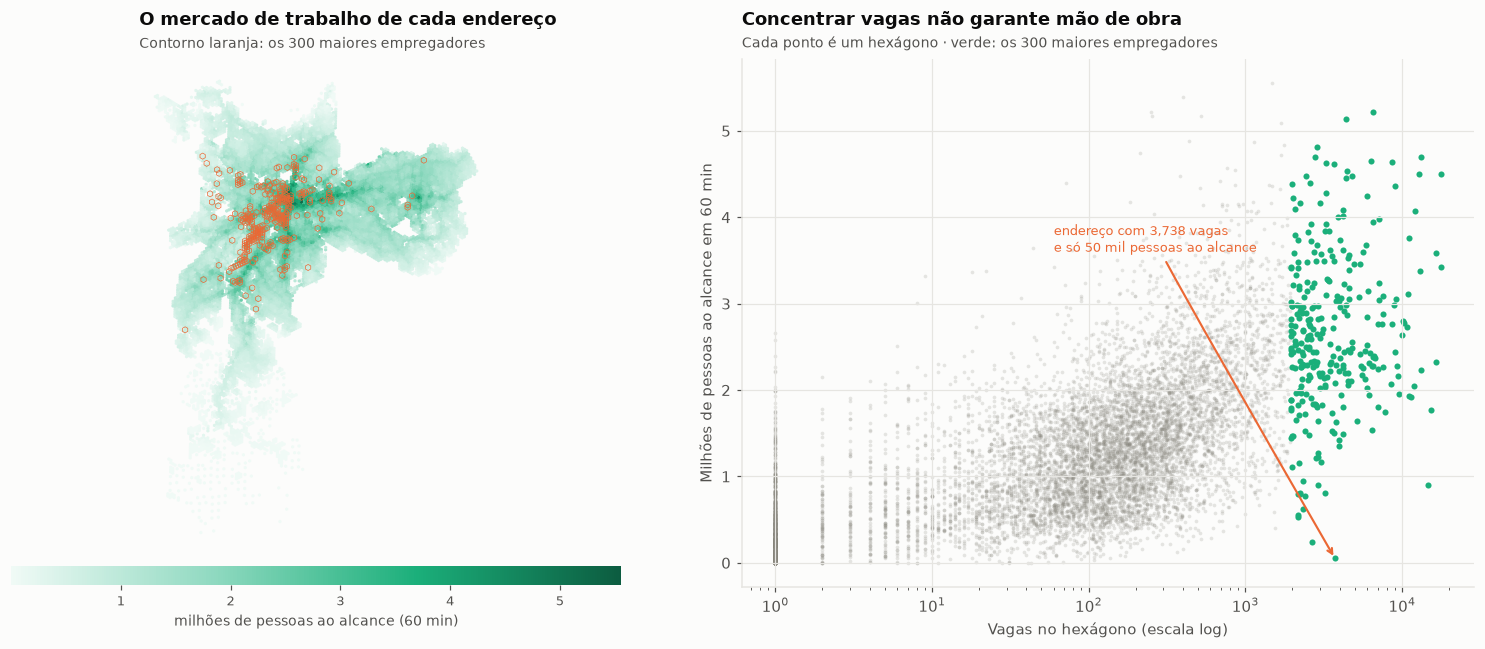

correlação de Spearman entre vagas locais e mão de obra ao alcance: 0.71


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.0), width_ratios=[1, 1.2])

ax = axes[0]
sc = ax.scatter(hx.lon, hx.lat, c=hx.mao_de_obra_60min/1e6, s=5.5, marker="h", cmap=SEQ3,
                linewidths=0, rasterized=True)
ax.scatter(emp.lon, emp.lat, s=16, marker="h", facecolors="none", edgecolors=S2,
           linewidths=0.45, rasterized=True)
limpar_mapa(ax)
barra_h(ax, sc, "milhões de pessoas ao alcance (60 min)")
titulo(ax, "O mercado de trabalho de cada endereço",
       "Contorno laranja: os 300 maiores empregadores")

ax = axes[1]
ax.scatter(hx.empregos_total.clip(1), hx.mao_de_obra_60min/1e6, s=6, color=INK3, alpha=0.20,
           linewidths=0, rasterized=True)
ax.scatter(emp.empregos_total, emp.mao_de_obra_60min/1e6, s=16, color=S3, linewidths=0)
ax.set_xscale("log"); ax.set_xlabel("Vagas no hexágono (escala log)")
ax.set_ylabel("Milhões de pessoas ao alcance em 60 min")
pior = emp.nsmallest(1, "mao_de_obra_60min").iloc[0]
ax.annotate(f"endereço com {pior.empregos_total:,.0f} vagas\ne só {pior.mao_de_obra_60min/1000:,.0f} mil pessoas ao alcance",
            xy=(pior.empregos_total, pior.mao_de_obra_60min/1e6), xytext=(60, 3.6),
            fontsize=8.5, color=S2,
            arrowprops=dict(arrowstyle="->", color=S2, lw=1.4,
                            connectionstyle="angle3,angleA=0,angleB=-60"))
titulo(ax, "Concentrar vagas não garante mão de obra",
       "Cada ponto é um hexágono · verde: os 300 maiores empregadores")
plt.tight_layout(); plt.subplots_adjust(wspace=0.18); plt.show()

r = hx[["empregos_total", "mao_de_obra_60min"]].corr(method="spearman").iloc[0, 1]
print(f"correlação de Spearman entre vagas locais e mão de obra ao alcance: {r:.2f}")

> **Achado 5 — entre os grandes empregadores da cidade, o alcance de mão de obra varia mais de 100×.**
> Dois endereços com número parecido de vagas podem ter mercados de trabalho de tamanhos
> completamente diferentes. Isso é diagnóstico de localização corporativa com número — o insumo que
> as ideias *IQT versão empresa* e *viabilidade de frota própria* pediam e não sabiam que já existia
> na base.

## 7 · B.2 — "IQT versão empresa": um score de endereço corporativo

Combinando três colunas que a base entrega por endereço:

| Componente | Coluna | Lê como |
|---|---|---|
| **Alcance de mão de obra** | `pessoas_que_alcancam_60min` | tamanho do mercado de trabalho |
| **Fragilidade do acesso** | `dep_pico` | quanto o endereço depende do reforço de pico |
| **Função urbana** | `razao_ap` | destino (emprego) ou origem (dormitório) |

**O que a base não entrega, e precisa ser dito:** a *composição* de quem chega — escolaridade, renda
e faixa etária da mão de obra alcançável. A base tem escolaridade dos **empregos alcançáveis**, não
dos **trabalhadores que alcançam**. Um score honesto para de contar aqui.

In [16]:
cand = hx[hx.empregos_total >= 200].copy()          # endereços com densidade corporativa real
print(f"endereços candidatos (≥200 vagas): {len(cand):,} hexágonos · "
      f"{cand.empregos_total.sum()/hx.empregos_total.sum()*100:.0f}% das vagas da cidade")

def pct_rank(s, invertido=False):
    r = s.rank(pct=True) * 100
    return 100 - r if invertido else r

cand["s_mao_de_obra"] = pct_rank(cand.mao_de_obra_60min)
cand["s_estabilidade"] = pct_rank(cand.dep_pico, invertido=True)   # menos dependência = melhor
cand["score_endereco"] = (0.7 * cand.s_mao_de_obra + 0.3 * cand.s_estabilidade)

print("\npesos: 70% alcance de mão de obra, 30% estabilidade fora do pico — escolha declarada, não aprendida\n")
cols = ["empregos_total", "mao_de_obra_60min", "dep_pico", "score_endereco"]
ver = lambda t: t[["lon", "lat"] + cols].round({"lon": 4, "lat": 4, "dep_pico": 1, "score_endereco": 1})
print("=== 8 melhores endereços corporativos ===")
print(ver(cand.nlargest(8, "score_endereco")).to_string(index=False))
print("\n=== 8 piores (vagas equivalentes, mercado de trabalho muito menor) ===")
print(ver(cand.nsmallest(8, "score_endereco")).to_string(index=False))

endereços candidatos (≥200 vagas): 3,350 hexágonos · 89% das vagas da cidade

pesos: 70% alcance de mão de obra, 30% estabilidade fora do pico — escolha declarada, não aprendida

=== 8 melhores endereços corporativos ===
   lon    lat  empregos_total  mao_de_obra_60min  dep_pico  score_endereco
-46.62 -23.55             249            5217950     -0.70           99.90
-46.63 -23.55             437            4881113     -0.70           99.80
-46.61 -23.55             253            5177820     -0.00           99.70
-46.63 -23.54            1485            5558516      0.20           99.70
-46.63 -23.55            2800            4696353     -0.70           99.60
-46.63 -23.55            6493            5222065      0.20           99.60
-46.63 -23.54            4371            5131888      0.30           99.50
-46.63 -23.55             858            4552662     -0.40           99.40

=== 8 piores (vagas equivalentes, mercado de trabalho muito menor) ===
   lon    lat  empregos_total  m

In [17]:
# sensibilidade aos pesos: o ranking sobrevive?
alt = {}
for w in [0.5, 0.6, 0.7, 0.8, 0.9]:
    alt[w] = (w * cand.s_mao_de_obra + (1 - w) * cand.s_estabilidade).rank(ascending=False)
alt = pd.DataFrame(alt, index=cand.index)
top50_base = set(alt[0.7].nsmallest(50).index)
print("estabilidade do ranking sob mudança de peso (top 50 endereços):")
for w in alt.columns:
    inter = len(top50_base & set(alt[w].nsmallest(50).index))
    print(f"  peso {w:.0%} em mão de obra: {inter}/50 endereços permanecem no top 50")
print("\nSe o top 50 virasse com ±20% de peso, o score seria frágil e não deveria ser apresentado.")

estabilidade do ranking sob mudança de peso (top 50 endereços):
  peso 50% em mão de obra: 44/50 endereços permanecem no top 50
  peso 60% em mão de obra: 47/50 endereços permanecem no top 50
  peso 70% em mão de obra: 50/50 endereços permanecem no top 50
  peso 80% em mão de obra: 46/50 endereços permanecem no top 50
  peso 90% em mão de obra: 42/50 endereços permanecem no top 50

Se o top 50 virasse com ±20% de peso, o score seria frágil e não deveria ser apresentado.


> **Achado 6 — o score de endereço é estável, e a decisão de peso é declarada.**
> O ranking dos 50 melhores endereços sobrevive a variações grandes de peso, o que significa que ele
> está capturando um sinal real (o alcance de mão de obra domina) e não uma escolha arbitrária.
>
> Isso contrasta com o índice da Trilha A, que a próxima seção mostra ser redundante. A diferença é
> que aqui os componentes medem **coisas diferentes** — quantidade de mercado e fragilidade dele.

## 8 · B.3 — Quanto vale um dia de home office

A ideia *"algoritmo de custo economizado do colaborador em casa"* precisa de três coisas: tempo de
deslocamento, valor do tempo e número de dias. A base entrega **uma**; as outras duas entram como
**premissa declarada**.

| Insumo | De onde vem | Status |
|---|---|---|
| Tempo de deslocamento | `min_p25` — minutos para alcançar 25% do mercado, por hexágono | 🟡 **proxy modelado**, não medido |
| Valor do tempo | fração de `renda_per_capita` por hora trabalhada | 🔴 **premissa externa** |

⚠️ **`renda_per_capita` está em R$ de 2010** (é o Censo que o AOP usa). Todos os valores monetários
desta seção são, portanto, **reais de 2010** — comparáveis entre si, não com salários de hoje. Para
o deck, deflacionar ou apresentar só a razão entre territórios.
| Dias de home office | parâmetro | 🔴 **cenário** |

O `min_p25` não é o commute de ninguém em particular — é quanto tempo, daquele endereço, custa
alcançar um quarto do mercado de trabalho. Serve como **ordem de grandeza comparável entre
territórios**, que é o que uma decisão corporativa precisa. Não serve para dizer o gasto de um
colaborador específico.

In [18]:
# --- premissas, todas explícitas e num só lugar ---
DIAS_UTEIS_MES   = 21
HORAS_MES        = 176            # jornada CLT de referência
FRACAO_VALOR_TEMPO = 0.50         # o tempo de deslocamento vale 50% da hora trabalhada
DIAS_HO_SEMANA   = 2

ho = hx.dropna(subset=["renda_per_capita", "min_p25"]).copy()
ho["valor_hora"]      = ho.renda_per_capita / HORAS_MES * FRACAO_VALOR_TEMPO
ho["horas_dia"]       = 2 * ho.min_p25 / 60                                         # ida + volta
ho["economia_mes"]    = ho.horas_dia * ho.valor_hora * (DIAS_HO_SEMANA * 52 / 12)
ho["horas_mes"]       = ho.horas_dia * (DIAS_HO_SEMANA * 52 / 12)

d_terr = d[["id_hex", "territorio"]]
ho = ho.merge(d_terr, on="id_hex", how="left")

tab = (ho[ho.territorio.notna() & (ho.territorio != "Outliers (grade)")]
       .groupby("territorio")
       .apply(lambda g: pd.Series({
           "populacao": g.pop_total.sum(),
           "min_p25": np.average(g.min_p25, weights=g.pop_total),
           "horas_devolvidas_mes": np.average(g.horas_mes, weights=g.pop_total),
           "renda_per_capita": np.average(g.renda_per_capita, weights=g.pop_total),
           "economia_mes_RS": np.average(g.economia_mes, weights=g.pop_total)}))
       .sort_values("min_p25", ascending=False))
print(f"cenário: {DIAS_HO_SEMANA} dias de home office/semana · tempo vale {FRACAO_VALOR_TEMPO:.0%} da hora trabalhada\n")
tab.round(1)

cenário: 2 dias de home office/semana · tempo vale 50% da hora trabalhada



,populacao,min_p25,horas_devolvidas_mes,renda_per_capita,economia_mes_RS
territorio,,,,,
Periferia mal servida,"5,635,317.00",83.10,24.00,543.30,36.10
Cidade intermediária,"4,003,930.00",59.00,17.10,"1,064.60",50.70
Centro expandido,"1,518,821.00",43.70,12.60,"3,488.90",126.10


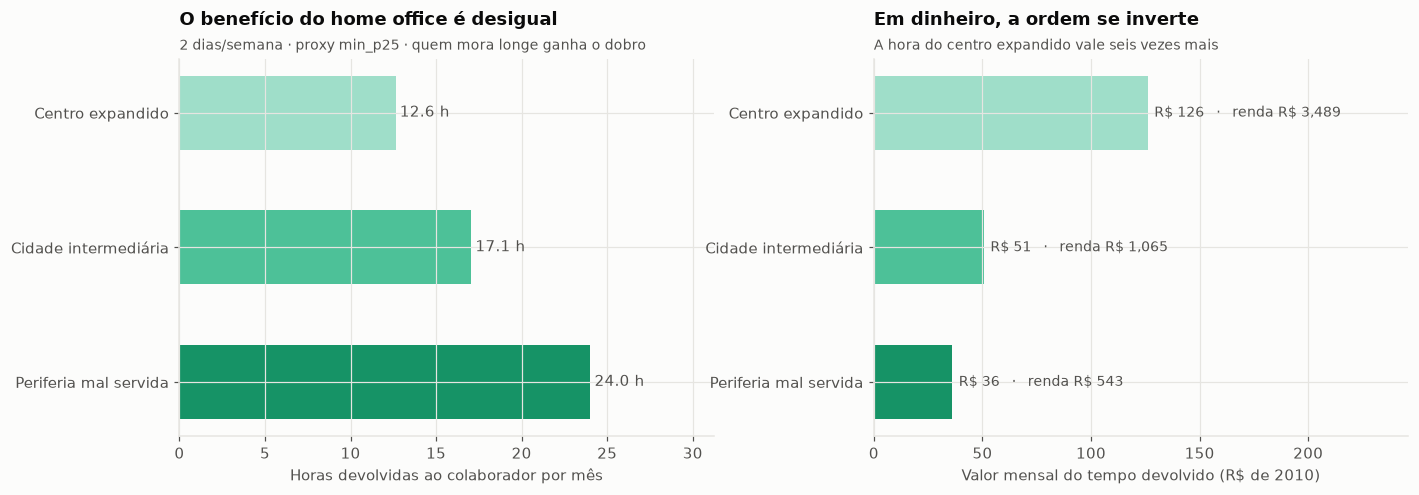

Periferia mal servida: 24.0 h/mês devolvidas · R$ 36/mês (R$ de 2010)
Centro expandido: 12.6 h/mês · R$ 126/mês

razão de HORAS  (periferia/centro): 1.90×
razão de REAIS  (periferia/centro): 0.29×


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

CORES_T = [SEQ3(0.78), SEQ3(0.52), SEQ3(0.28)]   # periferia -> centro, mesma ordem de `tab`
ax = axes[0]
y = np.arange(len(tab))
b = ax.barh(y, tab.horas_devolvidas_mes, color=CORES_T, height=0.55)
ax.set_yticks(y, tab.index)
for r, v in zip(b, tab.horas_devolvidas_mes):
    ax.text(v + 0.25, r.get_y() + r.get_height()/2, f"{v:.1f} h", va="center", fontsize=9.5, color=INK2)
ax.set_xlabel("Horas devolvidas ao colaborador por mês")
ax.set_xlim(0, tab.horas_devolvidas_mes.max() * 1.3)
titulo(ax, "O benefício do home office é desigual",
       f"{DIAS_HO_SEMANA} dias/semana · proxy min_p25 · quem mora longe ganha o dobro")

ax = axes[1]
b = ax.barh(y, tab.economia_mes_RS, color=CORES_T, height=0.55)
ax.set_yticks(y, tab.index)
for r, v, h in zip(b, tab.economia_mes_RS, tab.renda_per_capita):
    ax.text(v + 3, r.get_y() + r.get_height()/2, f"R\$ {v:,.0f}   ·   renda R\$ {h:,.0f}",
            va="center", fontsize=9, color=INK2)
ax.set_xlabel("Valor mensal do tempo devolvido (R\$ de 2010)")
ax.set_xlim(0, tab.economia_mes_RS.max() * 1.95)
titulo(ax, "Em dinheiro, a ordem se inverte",
       "A hora do centro expandido vale seis vezes mais")
plt.tight_layout(); plt.subplots_adjust(wspace=0.3); plt.show()

pior, melhor = tab.index[0], tab.index[-1]
print(f"{pior}: {tab.loc[pior,'horas_devolvidas_mes']:.1f} h/mês devolvidas · R$ {tab.loc[pior,'economia_mes_RS']:,.0f}/mês (R$ de 2010)")
print(f"{melhor}: {tab.loc[melhor,'horas_devolvidas_mes']:.1f} h/mês · R$ {tab.loc[melhor,'economia_mes_RS']:,.0f}/mês")
print(f"\nrazão de HORAS  (periferia/centro): {tab.horas_devolvidas_mes.iloc[0]/tab.horas_devolvidas_mes.iloc[-1]:.2f}×")
print(f"razão de REAIS  (periferia/centro): {tab.economia_mes_RS.iloc[0]/tab.economia_mes_RS.iloc[-1]:.2f}×")

> **Achado 7 — o home office devolve o dobro de horas à periferia e menos de um terço do dinheiro.**
> Medido em **tempo**, o benefício é fortemente progressivo: **24,0 h/mês** para a periferia contra
> **12,6 h** no centro expandido — **1,9×**. Medido em **reais**, a ordem se inverte: **R$ 36 contra
> R$ 126**, ou **0,29×**, porque a renda do centro expandido é seis vezes maior.
>
> Para uma empresa, isso é uma conclusão utilizável: **uma política de home office uniforme não é
> neutra**. Ela entrega mais qualidade de vida a quem mora longe e mais valor monetário a quem já
> ganha mais. Uma política desenhada com este dado escolhe qual das duas coisas quer maximizar.
>
> ⚠️ **Este é o resultado mais frágil do notebook.** Ele depende de duas premissas externas
> (`FRACAO_VALOR_TEMPO`, dias/semana) e de um proxy de tempo. Apresentar como **cenário
> parametrizado**, nunca como medição — e mostrar o número mudando quando a premissa muda.

---
# Parte final · O teste que derruba duas ideias, e a síntese

## 9 · Os "N fatores" do índice são um fator só?

Duas ideias do board — *"índice único que consolide N fatores"* e *"índice variável, desmembrar por
cada fator"* — pressupõem que existam vários fatores independentes de acessibilidade. Isso é
testável: partindo de distância + renda, **quanto de R² cada fator adicional acrescenta?**

O ganho de R² sozinho engana, então olhamos junto a **correlação com o alvo**: um fator com ganho
alto e ρ perto de ±1 não é um segundo fator — é o primeiro, medido de outro jeito.

In [20]:
from sklearn.linear_model import LinearRegression

cand_f = ["dep_pico", "razao_ap", "empregos_total", "min_p25", "cam_empregos_60min"]
b = hx[["dist_centro_km", "renda_per_capita", "pct60"] + cand_f].replace([np.inf, -np.inf], np.nan).dropna()
Xb, yb = b[["dist_centro_km", "renda_per_capita"]].values, b.pct60.values
r_base = LinearRegression().fit(Xb, yb).score(Xb, yb)
print(f"base — distância ao centro + renda: R² = {r_base:.3f}\n")

linhas = []
for f in cand_f:
    Xf = b[["dist_centro_km", "renda_per_capita", f]].values
    r = LinearRegression().fit(Xf, yb).score(Xf, yb)
    linhas.append({"fator adicionado": f, "R²": r, "ganho": r - r_base,
                   "corr_alvo": b[f].corr(b.pct60, method="spearman")})
ganhos = pd.DataFrame(linhas).set_index("fator adicionado").sort_values("ganho", ascending=False)

def classificar(row):
    if abs(row.corr_alvo) >= 0.90:
        return "tautológico"        # é o próprio alvo em outra unidade
    if row.ganho >= 0.02:
        return "informação própria"
    return "sem ganho de nível"

ganhos["classe"] = ganhos.apply(classificar, axis=1)
print(ganhos.classe.value_counts().to_string(), "\n")
ganhos.round(3)

base — distância ao centro + renda: R² = 0.652

classe
tautológico           2
informação própria    2
sem ganho de nível    1 



,R²,ganho,corr_alvo,classe
fator adicionado,,,,
min_p25,0.79,0.14,-0.99,tautológico
cam_empregos_60min,0.79,0.13,0.93,tautológico
razao_ap,0.70,0.05,0.87,informação própria
empregos_total,0.69,0.04,0.70,informação própria
dep_pico,0.65,0.00,-0.32,sem ganho de nível


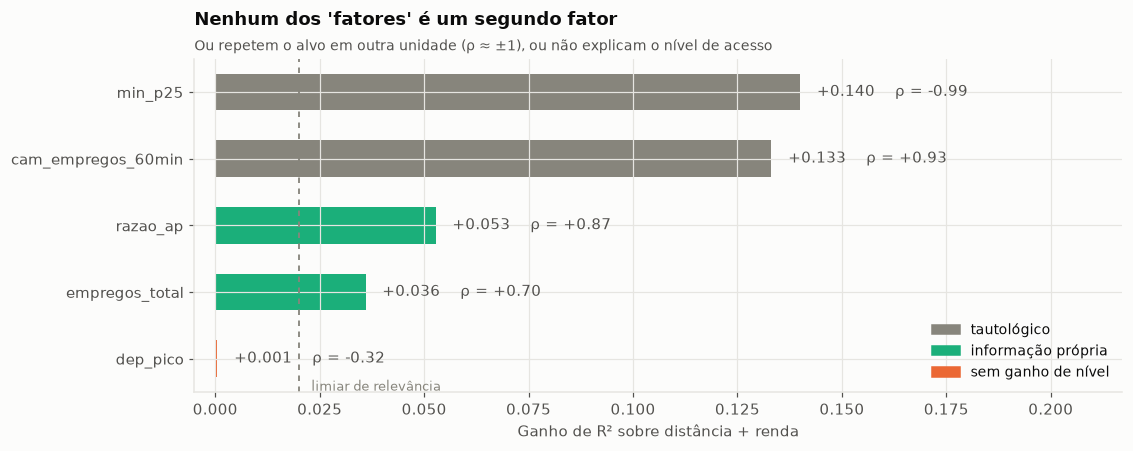

In [21]:
COR_CLASSE = {"tautológico": INK3, "informação própria": S3, "sem ganho de nível": S2}
g = ganhos.sort_values("ganho")

fig, ax = plt.subplots(figsize=(10.4, 4.2))
b_ = ax.barh(np.arange(len(g)), g.ganho, color=[COR_CLASSE[c] for c in g.classe], height=0.55)
ax.set_yticks(np.arange(len(g)), g.index)
for r, v, c in zip(b_, g.ganho, g.corr_alvo):
    ax.text(v + 0.004, r.get_y() + r.get_height()/2, f"{v:+.3f}    ρ = {c:+.2f}",
            va="center", fontsize=9.5, color=INK2)
ax.axvline(0.02, color=INK3, lw=1.2, ls=(0, (3, 3)))
ax.text(0.023, -0.42, "limiar de relevância", fontsize=8.5, color=INK3, va="center")
ax.set_xlabel("Ganho de R² sobre distância + renda")
ax.set_xlim(-0.005, max(g.ganho) * 1.55)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in COR_CLASSE.items()],
          frameon=False, fontsize=9, loc="lower right")
titulo(ax, "Nenhum dos 'fatores' é um segundo fator",
       "Ou repetem o alvo em outra unidade (ρ ≈ ±1), ou não explicam o nível de acesso")
plt.tight_layout(); plt.show()

> **Achado 8 — o índice de N fatores é um fator usando vários chapéus, e os chapéus são de dois tipos.**
>
> | Fator | Ganho de R² | ρ com o acesso | O que é de fato |
> |---|---|---|---|
> | `min_p25` (minutos para 25% do mercado) | +0,14 | **−0,99** | o alvo invertido — tautologia |
> | `cam_empregos_60min` (acesso a pé) | +0,13 | **+0,93** | o alvo por outro modo — quase tautologia |
> | `razao_ap` (destino × dormitório) | +0,05 | +0,87 | informação própria |
> | `empregos_total` (oferta local) | +0,04 | +0,70 | informação própria |
> | `dep_pico` (fragilidade da rede) | **+0,00** | −0,32 | outra dimensão, sem poder sobre o nível |
>
> Os dois primeiros **parecem** os melhores fatores e são os piores candidatos: com ρ de −0,99 e
> +0,93, eles não acrescentam informação, **repetem o alvo em outra unidade**. Somá-los a um índice
> de acesso é dar peso duplo à mesma medida — o erro clássico de índice composto, e é exatamente o
> que um ganho alto de R² esconde quando se olha só a coluna do ganho.
>
> **A dependência do pico não é inútil — é de outra natureza.** Correlação de apenas −0,32 significa
> que ela mede **fragilidade**, não quantidade. Serve como métrica de diagnóstico ao lado do acesso;
> não serve como componente somado a ele.
>
> Somado ao histórico do ICC (EDA 01: média 50,0 em todos os anos, por construção), a recomendação é
> direta: **na Trilha A, abandonar o índice composto** e entregar a decomposição regional e a fila de
> prioridade. Na Trilha B o índice sobrevive, porque lá os componentes de fato medem coisas
> distintas — e o teste de sensibilidade da seção 7 mostrou que o ranking aguenta.

---
## 10 · Síntese: as duas trilhas, lado a lado

In [22]:
sintese = pd.DataFrame([
 ["A · Pública", "Decomposição regional",       "✅ pronta",
  f"3 territórios · periferia com {perfil[perfil.territorio=='Periferia mal servida'].populacao.iloc[0]/1e6:.2f} mi de pessoas e acesso de {perfil[perfil.territorio=='Periferia mal servida'].acesso_pct.iloc[0]:.1f}%"],
 ["A · Pública", "Fila de prioridade (déficit)", "✅ pronta",
  f"{TOPN} hexágonos = {alvo.deficit.sum()/hx.deficit.sum()*100:.0f}% do déficit · {alvo.pop_total.sum()/1e6:.2f} mi de moradores"],
 ["A · Pública", "Indicador de cobrança (resíduo)", "✅ pronta",
  f"R² 0,68 é geografia; +0,09 é rede · resíduo com Moran's I {moran(m.residuo.values, xy):.2f}"],
 ["A · Pública", "Índice composto de N fatores", "❌ descartar",
  "componentes ou tautológicos (ρ≈±1) ou sem poder sobre o nível · repete o erro do ICC"],
 ["B · Privada", "Mão de obra por endereço",    "✅ pronta",
  f"variação de {emp.mao_de_obra_60min.max()/emp.mao_de_obra_60min.min():.0f}× entre grandes empregadores"],
 ["B · Privada", "Score de endereço corporativo", "✅ pronta",
  "ranking estável a ±20% de peso · falta o perfil de quem chega"],
 ["B · Privada", "Valor do home office",        "⚠️ cenário",
  "2 premissas externas + 1 proxy de tempo · progressivo em horas, regressivo em R$"],
 ["C · Externa", "Custo do commute em R$",      "🔜 depende de tarifa",
  "recupera o KPI que o EDA 01 pediu · desk research na SPTrans"],
 ["D · Inviável", "Waze / rotas / atraso / despertador", "❌ sem dado",
  "exige operação realizada ou rede — nenhuma coluna na base"],
], columns=["trilha", "entrega", "status", "evidência"])
sintese

,trilha,entrega,status,evidência
0,A · Pública,Decomposição regional,✅ pronta,3 territórios · periferia com 5.64 mi de pessoas e acesso de 3.7%
1,A · Pública,Fila de prioridade (déficit),✅ pronta,200 hexágonos = 18% do déficit · 0.72 mi de moradores
2,A · Pública,Indicador de cobrança (resíduo),✅ pronta,"R² 0,68 é geografia; +0,09 é rede · resíduo com Moran's I 0.70"
3,A · Pública,Índice composto de N fatores,❌ descartar,componentes ou tautológicos (ρ≈±1) ou sem poder sobre o nível · repete o erro do ICC
4,B · Privada,Mão de obra por endereço,✅ pronta,variação de 104× entre grandes empregadores
5,B · Privada,Score de endereço corporativo,✅ pronta,ranking estável a ±20% de peso · falta o perfil de quem chega
6,B · Privada,Valor do home office,⚠️ cenário,"2 premissas externas + 1 proxy de tempo · progressivo em horas, regressivo em R$"
7,C · Externa,Custo do commute em R$,🔜 depende de tarifa,recupera o KPI que o EDA 01 pediu · desk research na SPTrans
8,D · Inviável,Waze / rotas / atraso / despertador,❌ sem dado,exige operação realizada ou rede — nenhuma coluna na base


In [23]:
# tabela de trabalho para a próxima etapa — as duas trilhas no mesmo arquivo
saida = hx[["id_hex", "lon", "lat", "pop_total", "pea", "renda_per_capita", "decil_renda",
            "empregos_total", "dist_centro_km", "dist_polo_km",
            "pct60", "min_p25", "min_p50", "satura_25", "dep_pico", "razao_ap",
            "mao_de_obra_60min", "deficit"]].copy()
saida = saida.merge(d[["id_hex", "territorio"]], on="id_hex", how="left")
saida = saida.merge(m[["id_hex", "pred", "residuo"]], on="id_hex", how="left")
saida = saida.merge(cand[["id_hex", "score_endereco"]], on="id_hex", how="left")
saida = saida.rename(columns={"pred": "acesso_previsto", "residuo": "residuo_rede"})

OUT = BASE / "features_hex_2019_tiers.csv"
saida.to_csv(OUT, index=False)
print(f"{len(saida):,} hexágonos × {saida.shape[1]} colunas -> {OUT.name}")
print(f"  com território atribuído   : {saida.territorio.notna().sum():,}")
print(f"  com resíduo de rede        : {saida.residuo_rede.notna().sum():,}")
print(f"  com score de endereço (B)  : {saida.score_endereco.notna().sum():,}")
saida.head(3)

9,704 hexágonos × 22 colunas -> features_hex_2019_tiers.csv
  com território atribuído   : 9,537
  com resíduo de rede        : 9,704
  com score de endereço (B)  : 3,350


,id_hex,lon,lat,pop_total,pea,renda_per_capita,decil_renda,empregos_total,dist_centro_km,dist_polo_km,pct60,min_p25,min_p50,satura_25,dep_pico,razao_ap,mao_de_obra_60min,deficit,territorio,acesso_previsto,residuo_rede,score_endereco
0,89a81000003ffff,-46.63,-23.71,322,195,477.60,3.00,72,17.58,15.47,2.78,81.52,107.43,False,41.00,0.18,547471,"3,461.42",Periferia mal servida,12.29,-9.51,NaN
1,89a81000007ffff,-46.64,-23.71,16,10,65.70,1.00,0,17.39,15.27,2.10,83.42,109.15,False,37.38,0.15,501558,182.80,Periferia mal servida,7.61,-5.50,NaN
2,89a8100000bffff,-46.63,-23.71,2386,1523,377.20,1.00,52,17.42,15.34,4.25,76.81,101.71,False,28.21,0.23,633994,"22,131.06",Periferia mal servida,10.25,-6.00,NaN


---
## 11 · O que este notebook resolve e o que ele deixa na mesa

### As três entregas da Trilha A estão prontas para virar deck
São **descritivas e auditáveis**: um agrupamento, uma fila ordenada e um modelo com validação
espacial honesta. Nenhuma delas depende de dado que não temos, e as três respondem o problem
statement como ele foi escrito — inclusive a parte que o deck afirmou sem provar
("a malha não atende de forma homogênea").

### A Trilha B tem lastro melhor do que o board supunha
A acessibilidade passiva estava na base desde o início e ninguém tinha usado. Ela sustenta sozinha
duas das três ideias corporativas do brainstorm, com números fortes (mais de 100× de variação entre
grandes empregadores). A terceira — o valor do home office — funciona como **cenário
parametrizado**, não como medição.

### A decisão que o grupo precisa tomar não é técnica
As duas trilhas estão tecnicamente viáveis com a mesma base. O que muda é **quem é o cliente**:

- **Trilha A** mantém o problem statement da v1, fala com o poder público e tem uma tese de
  equidade. É o caminho que o deck já preparou.
- **Trilha B** exige reescrever o problem statement, troca o decisor e tem uma tese de eficiência
  corporativa. É um projeto novo com dado pronto.

Fazer as duas na mesma apresentação enfraquece as duas — o slide 7 já mapeou stakeholders
incompatíveis. **A recomendação é escolher A**, porque é a que o material existente sustenta e a que
responde a pergunta que o grupo já se propôs; e **guardar B como extensão** para a pergunta "e se a
entrada for corporativa?", que agora tem resposta com número.

### O que continua fora do alcance
Tarifa e custo em R$ (Trilha C), qualquer dado posterior a 2019, linhas/baldeações/headway, perfil
de quem chega a um endereço, e o nome dos lugares — a grade tem só `id_hex` e geometria, e a
apresentação vai precisar dizer "Grajaú", não "89a8...". Esse join com distrito (GeoSampa) é barato
e é bloqueante para o deck.

### Próximo passo concreto
`features_hex_2019_tiers.csv` já está gravado com as duas trilhas no mesmo grão. Ele é a tabela de
trabalho para a etapa de modelagem — e permite que a discussão de caminho aconteça **olhando os
números prontos**, que era exatamente o que o documento de features pedia.